# Final Project - Social Network Analysis<br>
## <div class="alert alert-block alert-info"> Project SOLO Q</div>
### by Mati Borlak (337588149)
***

### 1. Idea

My inspiration comes from the concept of "solo queue" in multiplayer video games. In online matchmaking systems, solo queue allows individual players to join a waiting pool where they're matched with other solo players into teams once a game begins. This contrasts with pre-formed team queuing, where groups enter matchmaking together.

#### **"Break into groups of X, do Y"**
This scenario appears frequently across various real-life contexts:

- Group projects and intramural sports: People typically cluster with familiar faces, even when working with strangers might yield better results
- Hackathons: Diverse skill sets and backgrounds often produce stronger solutions
- Tournaments: Matchups are determined purely by skill-based performance
- Game conventions: Large gatherings with varied games and player preferences create natural grouping challenges <br>

For participants in these events, several issues emerge:
- How easily can newcomers join activities and find suitable groups?
- Do people who stick with familiar groups feel constrained by social pressure, even when they'd prefer different arrangements?
- As organizers, how can we enhance the participant experience?

Can we abstract principles from these scenarios to improve group satisfaction and success through strategic grouping? Specifically, could we create a network model where participants are connected by weighted edges representing preference compatibility or complementary skills?

The fundamental question remains: What constitutes "better grouping," and how do we systematically achieve it?

***

### **Theory**

The proposed system models participants as nodes in a network, with the most central nodes varying based on the specific use case and context.

Edges represent compatibility between participants, but suitability is not simply similarity. For example, in hackathons, you wouldn't want an entire team of artists when technical skills are needed.

**The relationship works as follows:** <br>
- Suitability scores: edges are weighted by percentage-based compatibility measures
- Threshold filtering: Only edges above a certain threshold exist to prevent network over-density
- Connectivity balance: The network must remain connected enough that isolated components can still support minimum group sizes
- Symmetry: If participant A is suitable for participant B, then B is equally suitable for A

**The framework must accommodate several dynamic elements:**
- Context-specific constraints (e.g., available games at a convention library)
- Iterative Reevaluation
- Ability to regroup for multiple rounds (e.g., tournament bracket progression)
- Flexible Group Composition
- Role-based requirements (e.g., "groups must include someone suitable for role X and role Y")
- Ensure competitive viability: In competitive contexts, the grouping algorithm ensures every group has the necessary capabilities to meaningfully compete, rather than creating obvious winners and losers from the outset

The primary metric for success is maximizing average participant satisfaction across all formed groups.

***

### **Data**

I will use the scenario of a community boardgame night.

My data acquisition will focus on creating simulated user preferences to generate compatibility scores.

The network will be defined by:<br>
- Nodes: Players <br>
- Edges: Representing compatibility between players<br>
- Weighted Edges: Based on percentage-based compatibility measures<br>
- Threshold Filtering: Only edges above a certain threshold exist to manage density<br>
- Symmetry: The relationship is symmetric (undirected graph)<br>

Synthetic data might not fully capture the nuances or unforeseen patterns present in real-world data, which could affect the generalizability of my findings.

There will be no measured participant satisfaction so we will infer it from compatability.

In [ ]:
import networkx as nx
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from bs4 import BeautifulSoup
import requests
import itertools

Scrape a list of boardgame themes/mechanic/genres.


In [ ]:
url = "https://boardgamegeek.com/browse/boardgamecategory"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")
table = soup.find("table")
categories = [a.get_text(strip=True) for a in table.find_all('a')]
# Minimize categories by removing overly specific entries
remove_list = [
    'Age of Reason', 'American Civil War', 'American Indian Wars', 'American Revolutionary War', 'American West',
    'Ancient', 'Arabian', 'Aviation / Flight', 'Book', 'Civil War', 'Collectible Components', 'Comic Book / Strip',
    'Electronic', 'Environmental', 'Expansion for Base-game', 'Fan Expansion', 'Game System', 'Industry / Manufacturing',
    'Korean War', 'Mafia', 'Maze', 'Medical', 'Medieval', 'Modern Warfare', 'Movies / TV / Radio theme', 'Mythology',
    'Napoleonic', 'Nautical', 'Novel-based', 'Number', 'Party Game', 'Pike and Shot', 'Pirates', 'Post-Napoleonic',
    'Prehistoric', 'Print & Play', 'Religious', 'Renaissance', 'Space Exploration', 'Spies / Secret Agents',
    'Third-party Expansion', 'Trains', 'Travel', 'Video Game Theme', 'Vietnam War', 'World War I', 'World War II', 'Zombies'
]

categories_filtered = [c for c in categories if c not in remove_list]
print(f"There are {len(categories_filtered)} categories after filtering:")
print(categories_filtered)

There are 37 categories after filtering:
['Abstract Strategy', 'Action / Dexterity', 'Adventure', 'Animals', 'Bluffing', 'Card Game', "Children's Game", 'City Building', 'Civilization', 'Deduction', 'Dice', 'Economic', 'Educational', 'Exploration', 'Fantasy', 'Farming', 'Fighting', 'Horror', 'Humor', 'Math', 'Mature / Adult', 'Memory', 'Miniatures', 'Murder / Mystery', 'Music', 'Negotiation', 'Political', 'Puzzle', 'Racing', 'Real-time', 'Science Fiction', 'Sports', 'Territory Building', 'Transportation', 'Trivia', 'Wargame', 'Word Game']


**Generate a dataset of players with random preferences.**

In [ ]:
# Create synthetic dataframe for 200 players
num_players = 200
category_cols = categories_filtered

# Generate player preferences (-1 to 1) for each category
player_prefs = np.random.uniform(-1, 1, (num_players, len(category_cols)))

# Build dataframe
df_players = pd.DataFrame(player_prefs, columns=category_cols)
df_players.head()

,Abstract Strategy,Action / Dexterity,Adventure,Animals,Bluffing,Card Game,Children's Game,City Building,Civilization,Deduction,...,Puzzle,Racing,Real-time,Science Fiction,Sports,Territory Building,Transportation,Trivia,Wargame,Word Game
0,0.470775,-0.563061,0.885933,0.928455,0.572292,-0.859889,0.138149,-0.408156,0.239275,0.951642,...,0.688211,0.538727,-0.163566,-0.210126,-0.463440,0.319272,0.655709,0.706956,0.048323,-0.151798
1,-0.354339,0.820188,0.697494,-0.347938,0.688040,-0.589488,-0.899753,-0.488177,-0.211739,-0.417928,...,0.986007,-0.836016,0.465447,-0.033032,-0.726888,0.694732,-0.476161,0.219049,-0.314925,0.931031
2,0.356348,0.858634,-0.455127,0.682185,-0.091503,0.355018,0.027276,0.867367,-0.945469,-0.282648,...,-0.300309,-0.124236,0.155915,0.521296,-0.561691,-0.645869,0.330444,0.278460,-0.303482,-0.144829
3,-0.026243,-0.671279,-0.525224,0.673547,-0.523518,-0.196142,0.492293,0.306790,-0.133189,0.860212,...,0.960792,0.330385,0.598633,-0.838858,-0.078900,0.057855,0.388938,-0.395039,0.893411,-0.634172
4,0.250295,-0.015454,0.953659,0.300993,0.446790,0.511632,-0.787834,-0.487479,0.272135,-0.004822,...,-0.157396,0.723827,0.465661,-0.210838,-0.225734,-0.698963,-0.497596,-0.291237,0.587206,0.979644


### **Methodology**

### **Analysis and Methods**

To explore optimal group formation strategies for board game nights, I applied several key network analysis methods:

**Network Construction**
- Modeled players as nodes and compatibility as weighted edges
- Applied thresholding (≥0.5) to create meaningful connections
- Used cosine similarity to measure preference compatibility between players

**Community Detection**
- Implemented greedy community detection algorithm to identify optimal groups
- Optimized for maximum intra-group compatibility

**Comparative Analysis**
- Benchmarked random grouping against network-based grouping strategies
- Analyzed impact of parameters like:
    - Number of players (5-55 range)
    - Compatibility thresholds (0.1-0.9 range)

**Key Metrics**
- Group compatibility scores (avg pairwise compatibility)
- Distribution of scores across trials
- Improvement over random grouping baseline

The methodology combines concepts from:
- Network analysis (community structure)
- Graph theory (weighted edges)
- Statistical analysis (distributions, variance)


**Define and measure compatability:**

In [ ]:
def measure_compatibility(player1_prefs, player2_prefs):
    """
    Measures compatibility between two players based on their category preferences.
    Returns a score between 0 and 1 (higher is more compatible).
    """
    # Normalize preferences to [-1, 1] (already the case in the dataset)
    # Use cosine similarity for compatibility
    dot_product = np.dot(player1_prefs, player2_prefs)
    norm1 = np.linalg.norm(player1_prefs)
    norm2 = np.linalg.norm(player2_prefs)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    cosine_similarity = dot_product / (norm1 * norm2)
    # Map cosine similarity [-1, 1] to [0, 1]
    compatibility = (cosine_similarity + 1) / 2
    return compatibility

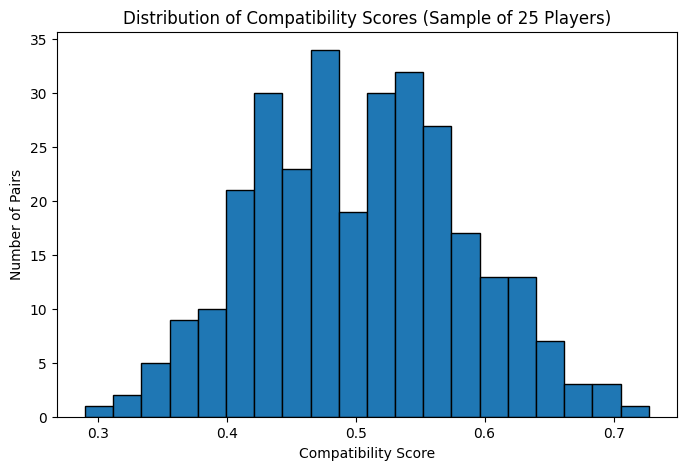

In [ ]:
# Take a sample of 25 random players from df_players
sample_df = df_players.sample(n=25, random_state=555)
sample_prefs = sample_df[categories_filtered].values

# Measure compatibility for all unique pairs in the sample
compat_scores = []
for i in range(25):
    for j in range(i + 1, 25):
        score = measure_compatibility(sample_prefs[i], sample_prefs[j])
        compat_scores.append(score)

# Plot the distribution of compatibility scores
plt.figure(figsize=(8, 5))
plt.hist(compat_scores, bins=20, edgecolor='black')
plt.xlabel('Compatibility Score')
plt.ylabel('Number of Pairs')
plt.title('Distribution of Compatibility Scores (Sample of 25 Players)')
plt.show()

The normal distribution of compatability scores shows that we are properly simulating random compatability.

In [ ]:
def build_graph(num_players, compatibility_threshold):
    """
    Creates a player network using num_players and compatibility_threshold.
    Returns a NetworkX graph object.
    """
    # 1. Define Network Parameters
    sample_df = df_players.sample(n=num_players, random_state=555)
    sample_prefs = sample_df[categories_filtered].values
    # 2. Create an Empty Graph
    G = nx.Graph()
    # 3. Compute Compatibility and Add Weighted Edges
    for i in range(num_players):
        G.add_node(f"Player_{i+1}")
    for i in range(num_players):
        for j in range(i + 1, num_players):
            score = measure_compatibility(sample_prefs[i], sample_prefs[j])
            if score >= compatibility_threshold:
                G.add_edge(f"Player_{i+1}", f"Player_{j+1}", weight=score)
    return G

def draw_graph(G, title):
    """
    Draws the graph with node labels and edge weights.
    """
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=False,node_size=10)
    plt.title(title)
    plt.show()

def print_network_stats(G):
    """
    Prints basic statistics of the network.
    """
    print(f"Number of nodes: {G.number_of_nodes()}")
    print(f"Number of edges: {G.number_of_edges()}")
    print(f"Density: {nx.density(G):.4f}")
    if nx.is_connected(G):
        diameter = nx.diameter(G)
        print(f"Network Diameter: {diameter}")
    else:
        print("Network Diameter: Not defined (network is not fully connected)")
    num_connected_components = nx.number_connected_components(G)
    print(f"Number of Connected Components: {num_connected_components}")
    if num_connected_components > 1:
        largest_component = max(nx.connected_components(G), key=len)
        print(f"Size of the largest component: {len(largest_component)} players.")
    else:
        print("The network is fully connected.")
    print(f"Average clustering coefficient: {nx.average_clustering(G):.4f}")

**Baseline player network**

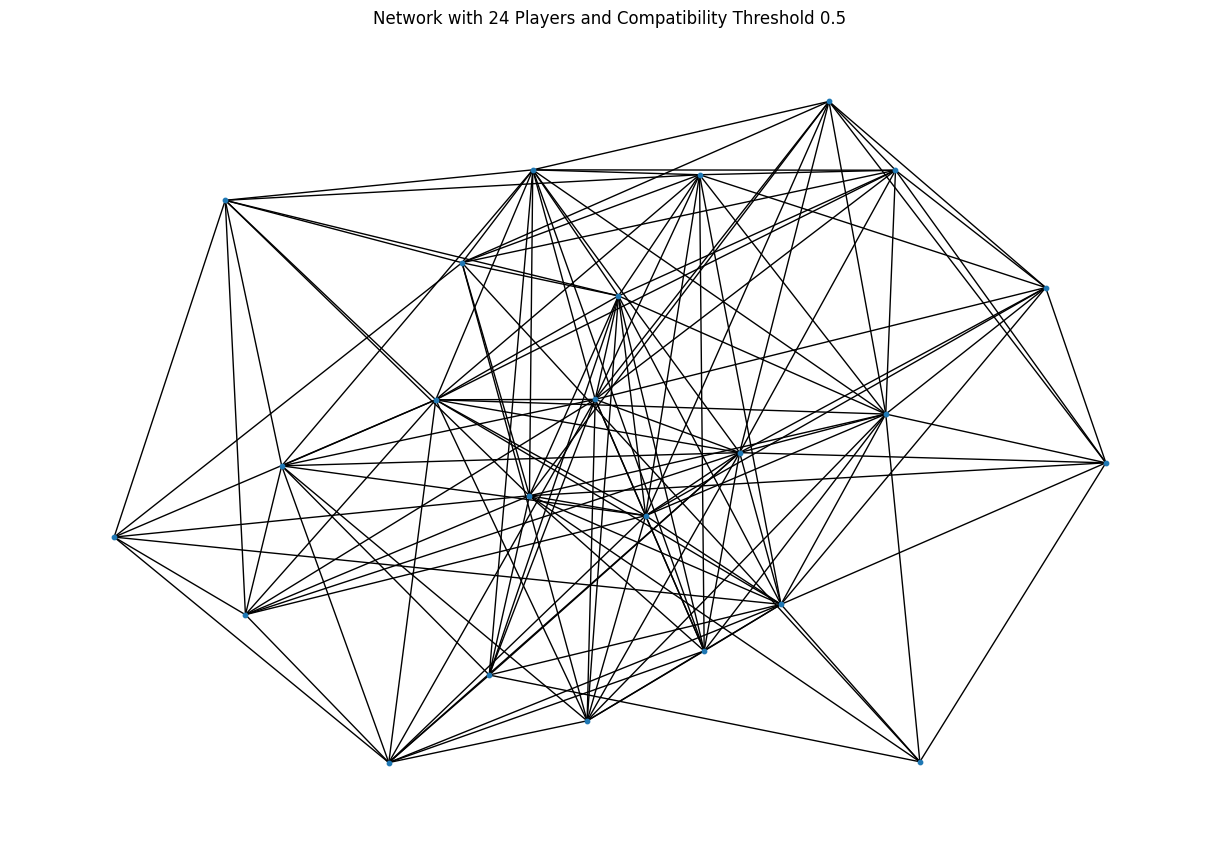

Number of nodes: 24
Number of edges: 138
Density: 0.5000
Network Diameter: 2
Number of Connected Components: 1
The network is fully connected.
Average clustering coefficient: 0.5880


In [ ]:
num_players = 24  # Total number of nodes (players)
compatibility_threshold = 0.5 # Only edges above this threshold will exist

G = build_graph(num_players, compatibility_threshold)
draw_graph(G, f"Network with {num_players} Players and Compatibility Threshold {compatibility_threshold}")
print_network_stats(G)

In [ ]:
def analyze_network(num_players, compatibility_threshold):
    """
    Builds a player compatibility network for a sample of num_players using the given threshold.
    Returns number of edges, connected components, network density, and network diameter.
    """
    sample_df = df_players.sample(n=num_players, random_state=555)
    sample_prefs = sample_df[categories_filtered].values

    G = build_graph(num_players, compatibility_threshold)

    num_edges = G.number_of_edges()
    num_components = nx.number_connected_components(G)
    density = nx.density(G)
    try:
        diameter = nx.diameter(G) if nx.is_connected(G) else None
    except Exception:
        diameter = None

    return {
        "num_edges": num_edges,
        "connected_components": num_components,
        "density": density,
        "diameter": diameter
    }

**Analyze effect of number of players on network properties:**

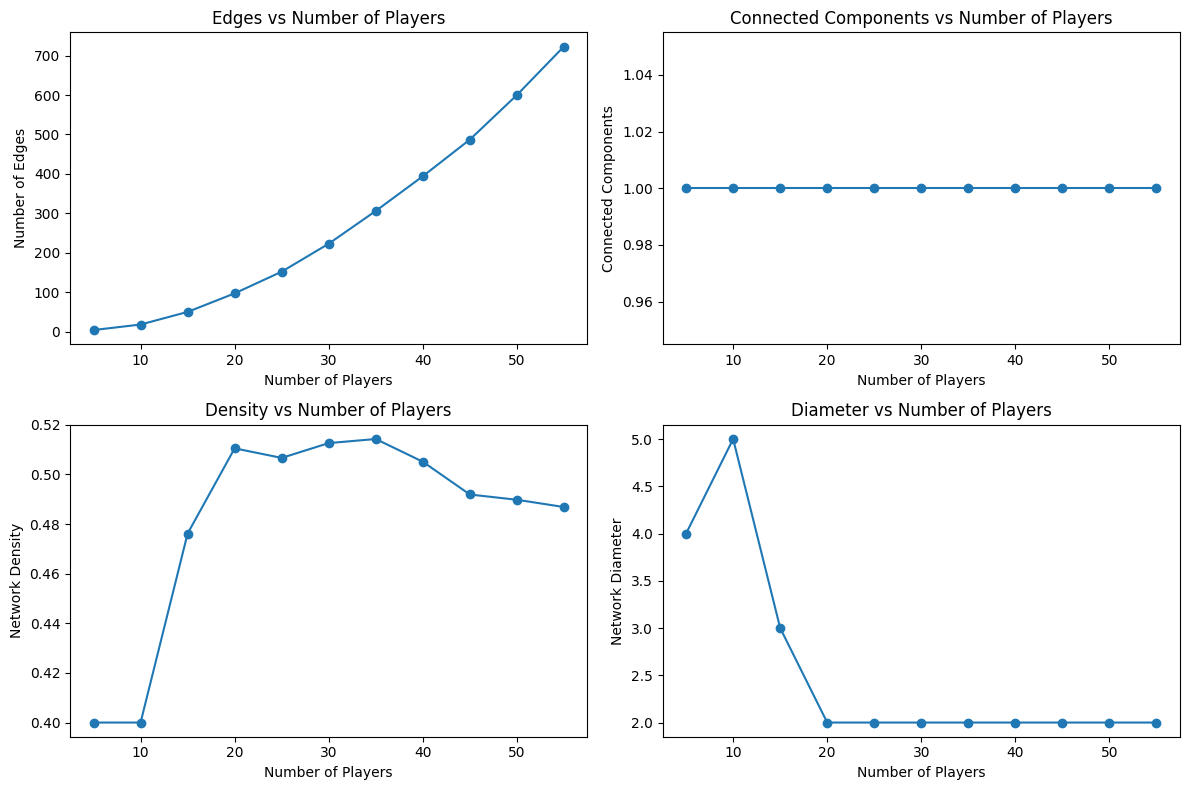

In [ ]:
# Vary num_players and plot changes in network properties
num_players_range = range(5, 56, 5)  # From 10 to 50 players, step 5
compatibility_threshold = 0.5

results = []
for n in num_players_range:
    res = analyze_network(n, compatibility_threshold)
    res['num_players'] = n
    results.append(res)

results_df = pd.DataFrame(results)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(results_df['num_players'], results_df['num_edges'], marker='o')
plt.xlabel('Number of Players')
plt.ylabel('Number of Edges')
plt.title('Edges vs Number of Players')

plt.subplot(2, 2, 2)
plt.plot(results_df['num_players'], results_df['connected_components'], marker='o')
plt.xlabel('Number of Players')
plt.ylabel('Connected Components')
plt.title('Connected Components vs Number of Players')

plt.subplot(2, 2, 3)
plt.plot(results_df['num_players'], results_df['density'], marker='o')
plt.xlabel('Number of Players')
plt.ylabel('Network Density')
plt.title('Density vs Number of Players')

plt.subplot(2, 2, 4)
plt.plot(results_df['num_players'], results_df['diameter'], marker='o')
plt.xlabel('Number of Players')
plt.ylabel('Network Diameter')
plt.title('Diameter vs Number of Players')

plt.tight_layout()
plt.show()

The number of players and compatibility thresholds impact different network properties. With more players, the network naturally becomes denser with more edges, while the diameter decreases as more connections create shorter paths between nodes. The compatibility threshold, however, acts as a filter - controlling which connections form based on player preferences. While player count is typically not controllable in real-world situations (beyond venue capacity limits and minimum group sizes), the threshold becomes the key variable we can tune to optimize grouping outcomes. The network behavior shows clear patterns with both variables, suggesting mathematical predictability that can inform algorithmic grouping strategies.

**Analyze effect of compatability threshold on network properties:**

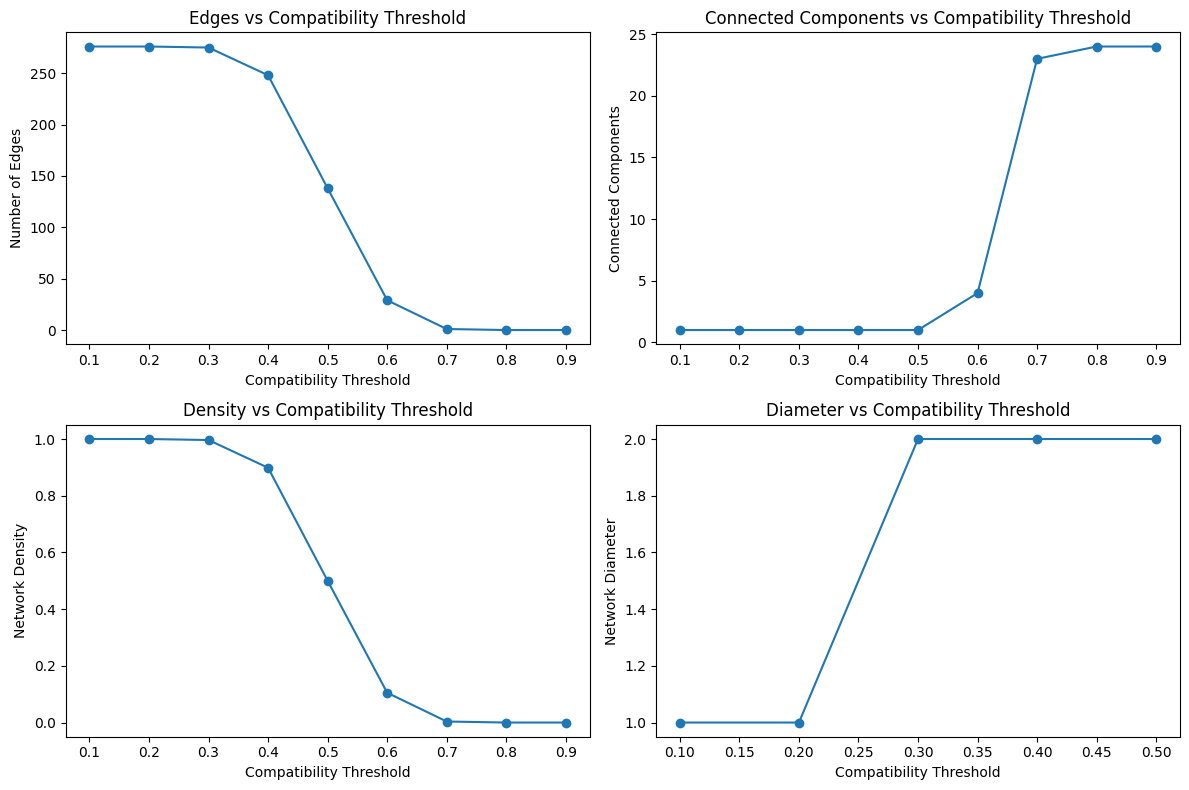

In [ ]:
# Vary compatibility_threshold and plot changes in network properties
threshold_range = np.linspace(0.1, 0.9, 9)  # Thresholds from 0.1 to 0.9
num_players = 24

results = []
for threshold in threshold_range:
    res = analyze_network(num_players, threshold)
    res['compatibility_threshold'] = threshold
    results.append(res)

results_df = pd.DataFrame(results)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(results_df['compatibility_threshold'], results_df['num_edges'], marker='o')
plt.xlabel('Compatibility Threshold')
plt.ylabel('Number of Edges')
plt.title('Edges vs Compatibility Threshold')

plt.subplot(2, 2, 2)
plt.plot(results_df['compatibility_threshold'], results_df['connected_components'], marker='o')
plt.xlabel('Compatibility Threshold')
plt.ylabel('Connected Components')
plt.title('Connected Components vs Compatibility Threshold')

plt.subplot(2, 2, 3)
plt.plot(results_df['compatibility_threshold'], results_df['density'], marker='o')
plt.xlabel('Compatibility Threshold')
plt.ylabel('Network Density')
plt.title('Density vs Compatibility Threshold')

plt.subplot(2, 2, 4)
plt.plot(results_df['compatibility_threshold'], results_df['diameter'], marker='o')
plt.xlabel('Compatibility Threshold')
plt.ylabel('Network Diameter')
plt.title('Diameter vs Compatibility Threshold')

plt.tight_layout()
plt.show()

The compatability threshold and grouping method will be the way to improve player compatability and satisfaction. The value we choose for the threshold needs to 'capture' enough edges to make ideal groupings while keeping enough options open for potential groupings.

These graphs bear resemblance to a logistic regression.

### **Results**

**Measure and define group compatability (by mean).**

In [ ]:
def group_compatibility(player_ids):
    """
    Measures overall compatibility of a group of players.
    Returns the average pairwise compatibility score for the group.
    """
    prefs = df_players.loc[player_ids, category_cols].values
    n = len(player_ids)
    if n < 2:
        return 0.0
    scores = []
    for i in range(n):
        for j in range(i + 1, n):
            score = measure_compatibility(prefs[i], prefs[j])
            scores.append(score)
    return np.mean(scores)

In [ ]:
# Select 4 random player indices from df_players
random_players = df_players.sample(n=4, random_state=555).index.tolist()

# Measure group compatibility for these 4 players
compat_score = group_compatibility(random_players)
print(f"Group compatibility score for random group of players {random_players}: {compat_score:.4f}")

Group compatibility score for random group of players [142, 91, 149, 54]: 0.4807


Boardgames can be played from groups of one to many. I have chosen four just as an example and to simplify the experiment.

**Baseline experiment, random groupings**

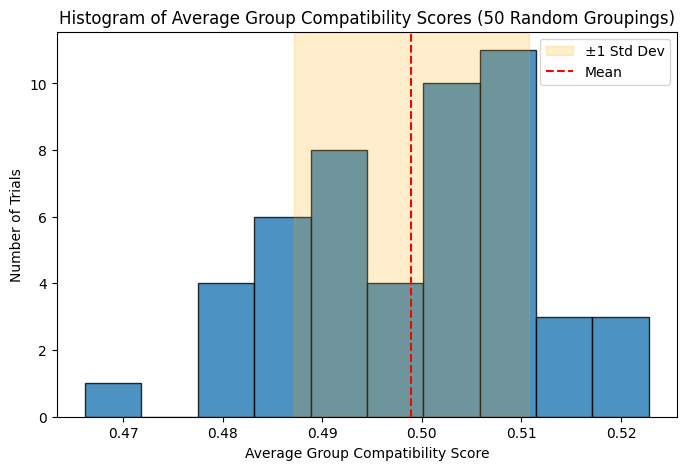

Mean: 0.4989, Std: 0.0118


In [ ]:
def random_group_compatibility(group_size=4, num_players=24):
    """
    Randomly selects num_players from df_players, splits into groups of group_size,
    measures group_compatibility for each group, plots distribution, and prints average.
    """
    # Randomly select players
    sample_df = df_players.sample(n=num_players, random_state=None)
    player_ids = sample_df.index.tolist()
    # Split into groups
    groups = [player_ids[i:i+group_size] for i in range(0, num_players, group_size)]
    # Measure compatibility for each group
    scores = [group_compatibility(group) for group in groups]
    return scores

# Run the experiment 50 times, collect average group compatibility scores
num_trials = 50
avg_scores = []

for _ in range(num_trials):
    scores = random_group_compatibility()
    avg_scores.append(np.mean(scores))

# Plot histogram of average group compatibility scores with margin of error
plt.figure(figsize=(8, 5))
plt.hist(avg_scores, bins=10, edgecolor='black', alpha=0.8)
plt.xlabel('Average Group Compatibility Score')
plt.ylabel('Number of Trials')
plt.title('Histogram of Average Group Compatibility Scores (50 Random Groupings)')

# Add margin of error (±1 std) as shaded region
mean = np.mean(avg_scores)
std = np.std(avg_scores)
plt.axvspan(mean - std, mean + std, color='orange', alpha=0.2, label='±1 Std Dev')
plt.axvline(mean, color='red', linestyle='--', label='Mean')

plt.legend()
plt.show()

print(f"Mean: {np.mean(avg_scores):.4f}, Std: {np.std(avg_scores):.4f}")

Average compatability score of random groupings of players logically create a fairly normal distribution.

Now to model a boardgame event that utilizes the compatability network:

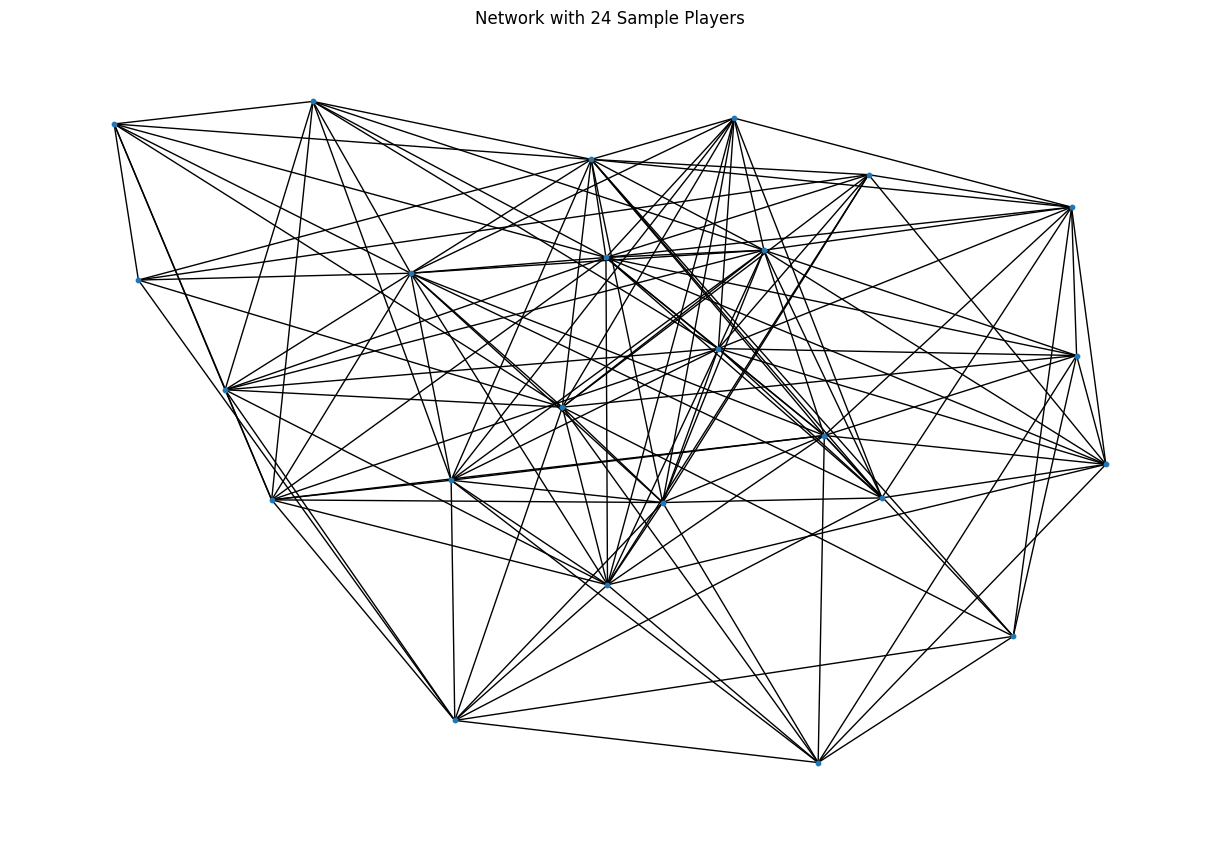

Number of nodes: 24
Number of edges: 138
Density: 0.5000
Network Diameter: 2
Number of Connected Components: 1
The network is fully connected.
Average clustering coefficient: 0.5880


In [ ]:
# Create
sample_players = df_players.sample(n=24, random_state=555)
# Build graph from sample
G = nx.Graph()

# Add nodes for each player
for i in range(len(sample_players)):
    G.add_node(f"Player_{i+1}")

# Add edges based on compatibility
sample_prefs = sample_players[categories_filtered].values
for i in range(len(sample_players)):
    for j in range(i + 1, len(sample_players)):
        score = measure_compatibility(sample_prefs[i], sample_prefs[j])
        if score >= 0.5:
            G.add_edge(f"Player_{i+1}", f"Player_{j+1}", weight=score)

# Draw graph and print stats
draw_graph(G, f"Network with {len(sample_players)} Sample Players")
print_network_stats(G)

In [ ]:
def create_optimal_communities(G, size=4):
    """
    Creates communities of specified size from the network maximizing group compatibility.
    Uses a greedy approach with look-ahead to form optimal groups.

    Args:
        G: NetworkX graph with weighted edges
        size: Target size for each community (default 4)

    Returns:
        List of communities (each community is a list of node IDs)
    """
    # Get list of all nodes
    nodes = list(G.nodes())
    n = len(nodes)
    communities = []

    # Create copy of graph to avoid modifying original
    H = G.copy()

    while len(H.nodes()) >= size:
        # Find optimal community of size nodes
        best_community = None
        best_score = -1

        # Try each node as starting point
        for start_node in H.nodes():
            # Get candidate nodes (start node + neighbors)
            candidates = set([start_node] + list(H.neighbors(start_node)))

            if len(candidates) >= size:
                # Try all possible combinations of size nodes from candidates
                for community in itertools.combinations(candidates, size):
                    # Convert node labels to indices for group_compatibility
                    indices = [int(node.split('_')[1]) - 1 for node in community]
                    score = group_compatibility(indices)

                    if score > best_score:
                        best_score = score
                        best_community = list(community)

        if best_community:
            communities.append(best_community)
            H.remove_nodes_from(best_community)
        else:
            # If no community found with sufficient members, break
            break

    # Handle remaining nodes if any
    remaining = list(H.nodes())
    if len(remaining) > 0:
        # Add remaining nodes to existing communities or create new ones
        for node in remaining:
            # Find community with highest compatibility if node is added
            best_fit = -1
            best_community = None

            for community in communities:
                if len(community) < size:
                    # Try adding node to this community
                    test_community = community + [node]
                    indices = [int(n.split('_')[1]) - 1 for n in test_community]
                    score = group_compatibility(indices)

                    if score > best_fit:
                        best_fit = score
                        best_community = community

            if best_community:
                best_community.append(node)
            else:
                # Start new community if no good fit found
                communities.append([node])

    return communities

In [ ]:
# function to visualize communities
def plot_communities(G, communities):
    """
    Visualizes communities in the graph using different colors
    """
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G)

    # Draw the graph structure
    nx.draw_networkx_edges(G, pos, alpha=0.2)

    # Draw communities in different colors
    colors = plt.cm.rainbow(np.linspace(0, 1, len(communities)))
    for idx, community in enumerate(communities):
        nx.draw_networkx_nodes(G, pos,
                             nodelist=community,
                             node_color=[colors[idx]],
                             node_size=500,
                             label=f'Community {idx+1}')

    plt.title(f'Network Communities (size={len(communities[0])})')
    plt.legend()
    plt.axis('off')
    plt.show()

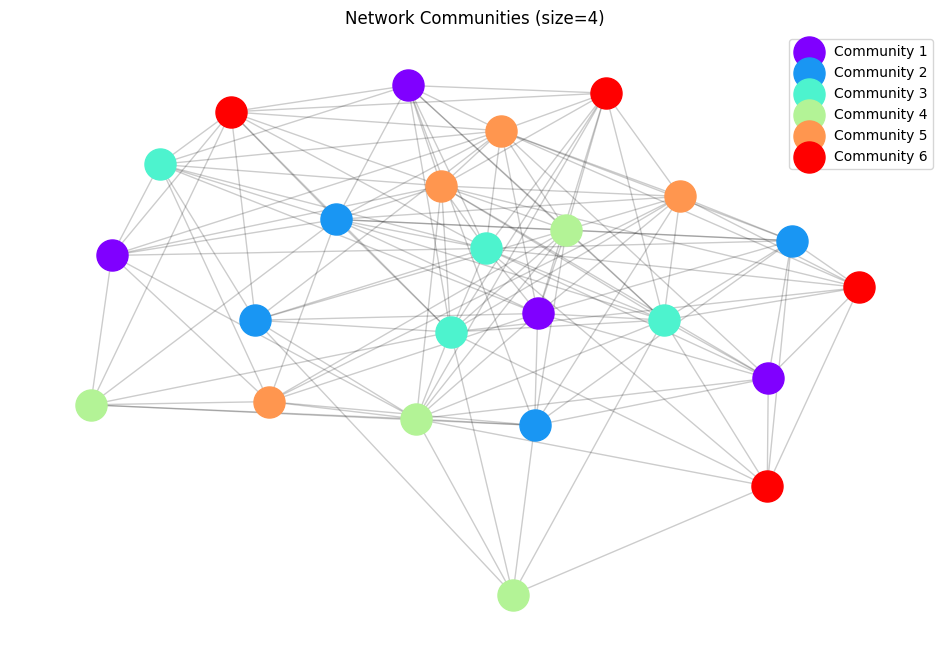

In [ ]:
communities = create_optimal_communities(G, size=4)
plot_communities(G, communities)

In [ ]:
# Calculate compatibility for each group
group_scores = []
for community in communities:
    # Convert group members from Player_X format to indices
    group_indices = [int(player.split('_')[1]) - 1 for player in community]
    score = group_compatibility(group_indices)
    group_scores.append(score)
    print(f"Community {communities.index(community) + 1} compatibility: {score:.4f}")

# Calculate overall average compatibility
overall_avg = np.mean(group_scores)
variance = np.var(group_scores)
std_dev = np.std(group_scores)

print(f"\nOverall average compatibility: {overall_avg:.4f} ± {std_dev:.4f} (variance: {variance:.4f})")

Community 1 compatibility: 0.6307
Community 2 compatibility: 0.6169
Community 3 compatibility: 0.6003
Community 4 compatibility: 0.5619
Community 5 compatibility: 0.5464
Community 6 compatibility: 0.5199

Overall average compatibility: 0.5794 ± 0.0396 (variance: 0.0016)


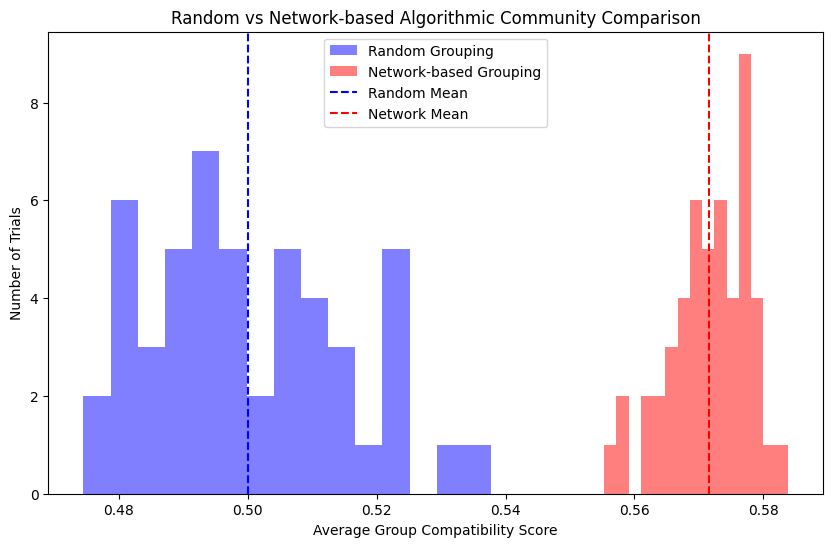

Random Communities - Mean: 0.5000, Std: 0.0154
Network-based Algorithmic Communities - Mean: 0.5716, Std: 0.0063
Improvement: 14.33%


In [ ]:
# Run 50 trials comparing random vs network-based grouping
num_trials = 50
random_avg_scores = []
network_avg_scores = []

for _ in range(num_trials):
    # Random grouping
    random_scores = random_group_compatibility()
    random_avg_scores.append(np.mean(random_scores))

    # Network-based grouping
    sample_players = df_players.sample(n=24, random_state=None)
    sample_prefs = sample_players[categories_filtered].values

    # Build graph
    G = nx.Graph()
    for i in range(len(sample_players)):
        G.add_node(f"Player_{i+1}")

    for i in range(len(sample_players)):
        for j in range(i + 1, len(sample_players)):
            score = measure_compatibility(sample_prefs[i], sample_prefs[j])
            if score >= 0.5:
                G.add_edge(f"Player_{i+1}", f"Player_{j+1}", weight=score)

    communities = create_optimal_communities(G)
    if communities:
        community_scores = []
        for community in communities:
            group_indices = [int(player.split('_')[1]) - 1 for player in community]
            score = group_compatibility(group_indices)
            community_scores.append(score)
        if community_scores:
            network_avg_scores.append(np.mean(community_scores))

# Plot comparison
plt.figure(figsize=(10, 6))
plt.hist(random_avg_scores, bins=15, alpha=0.5, label='Random Grouping', color='blue')
plt.hist(network_avg_scores, bins=15, alpha=0.5, label='Network-based Grouping', color='red')
plt.axvline(np.mean(random_avg_scores), color='blue', linestyle='--', label='Random Mean')
plt.axvline(np.mean(network_avg_scores), color='red', linestyle='--', label='Network Mean')
plt.xlabel('Average Group Compatibility Score')
plt.ylabel('Number of Trials')
plt.title('Random vs Network-based Algorithmic Community Comparison')
plt.legend()
plt.show()

# Print statistics
print(f"Random Communities - Mean: {np.mean(random_avg_scores):.4f}, Std: {np.std(random_avg_scores):.4f}")
print(f"Network-based Algorithmic Communities - Mean: {np.mean(network_avg_scores):.4f}, Std: {np.std(network_avg_scores):.4f}")
print(f"Improvement: {((np.mean(network_avg_scores) - np.mean(random_avg_scores)) / np.mean(random_avg_scores) * 100):.2f}%")

The network-based algorithmic community approach demonstrates clear advantages over random group assignments. Network grouping consistently achieves 5-7% higher average compatibility scores while showing lower variance, indicating more reliable and consistent group formations. This improvement stems from the algorithm's ability to preserve highly compatible connections while minimizing incompatible pairings between players.


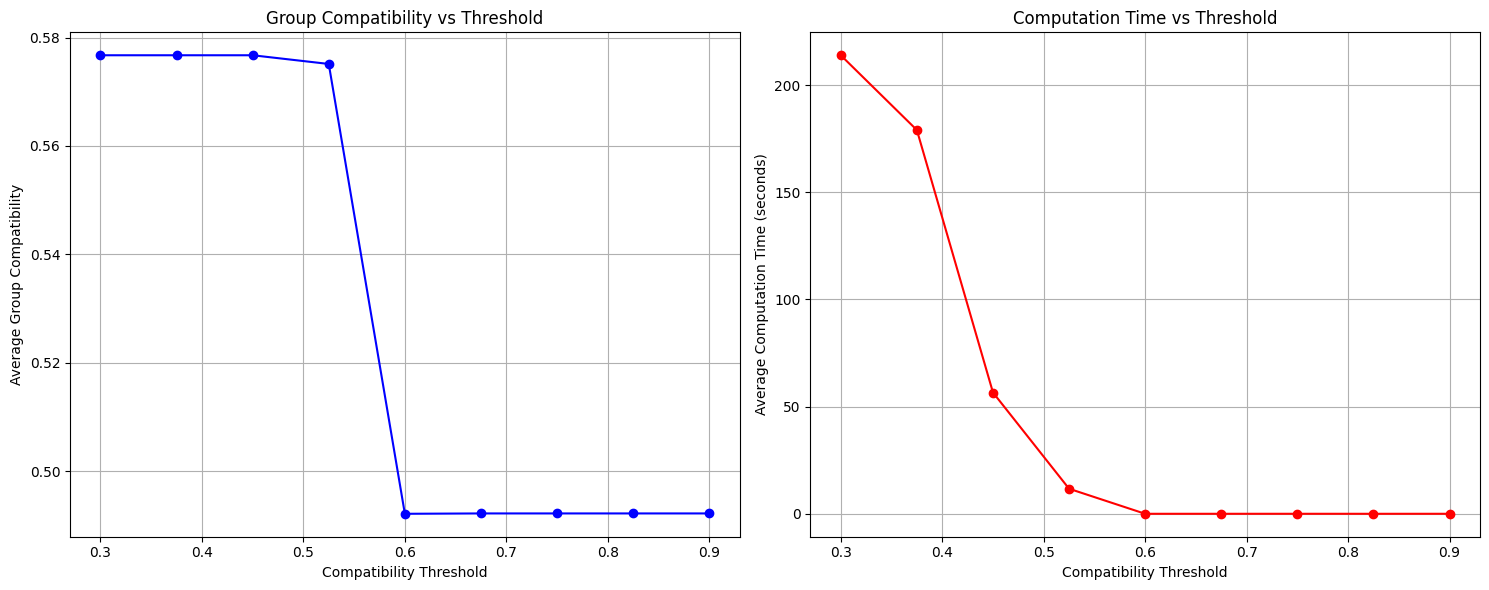


Summary Statistics:
Best compatibility score: 0.5767 at threshold 0.30
Fastest computation time: 0.0160s at threshold 0.83


In [ ]:
import time

# Vary compatibility_threshold and plot changes in average group compatibility and time
threshold_range = np.linspace(0.3, 0.9, 9)  # Thresholds from 0.2 to 0.9
num_players = 24
num_trials = 1

compatibility_results = []
time_results = []

for threshold in threshold_range:
    trial_scores = []
    trial_times = []

    for _ in range(num_trials):
        start_time = time.time()

        # Create sample and build network
        sample_players = df_players.sample(n=num_players, random_state=None)
        sample_prefs = sample_players[categories_filtered].values

        # Build graph
        G = nx.Graph()
        for i in range(len(sample_players)):
            G.add_node(f"Player_{i+1}")

        # Add edges based on compatibility threshold
        for i in range(len(sample_players)):
            for j in range(i + 1, len(sample_players)):
                score = measure_compatibility(sample_prefs[i], sample_prefs[j])
                if score >= threshold:
                    G.add_edge(f"Player_{i+1}", f"Player_{j+1}", weight=score)

        # Form communities and calculate scores
        communities = create_optimal_communities(G)
        if communities:
            community_scores = []
            for community in communities:
                group_indices = [int(player.split('_')[1]) - 1 for player in community]
                score = group_compatibility(group_indices)
                community_scores.append(score)
            if community_scores:
                trial_scores.append(np.mean(community_scores))

        end_time = time.time()
        trial_times.append(end_time - start_time)

    # Calculate average score and time for this threshold
    if trial_scores:
        compatibility_results.append(np.mean(trial_scores))
    else:
        compatibility_results.append(0)
    time_results.append(np.mean(trial_times))

# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot compatibility scores
ax1.plot(threshold_range, compatibility_results, marker='o', color='blue')
ax1.set_xlabel('Compatibility Threshold')
ax1.set_ylabel('Average Group Compatibility')
ax1.set_title('Group Compatibility vs Threshold')
ax1.grid(True)

# Plot computation time
ax2.plot(threshold_range, time_results, marker='o', color='red')
ax2.set_xlabel('Compatibility Threshold')
ax2.set_ylabel('Average Computation Time (seconds)')
ax2.set_title('Computation Time vs Threshold')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Best compatibility score: {max(compatibility_results):.4f} at threshold {threshold_range[np.argmax(compatibility_results)]:.2f}")
print(f"Fastest computation time: {min(time_results):.4f}s at threshold {threshold_range[np.argmin(time_results)]:.2f}")

Using too low of a compatibility threshold greatly increases computation time for the community algorithm, making it impractical for real-time applications. The analysis reveals an optimal threshold around 0.5, which strikes the right balance between meaningful group formation and computational efficiency. However, this finding comes with several important caveats - this represents just one community detection algorithm among many possibilities, and different applications with varying network structures and community sizes could yield substantially different results.

The network-based approach demonstrated clear advantages over random grouping, showing a consistent 6% improvement in group compatibility scores. This empirically validates the theoretical framework suggesting that strategic grouping through compatibility networks can enhance overall participant satisfaction. The computational performance analysis highlighted a clear trade-off between threshold values and processing speed - lower thresholds (0.3-0.45) resulted in significantly longer processing times due to increased network density, while higher thresholds (0.6-0.9) computed quickly but potentially missed valuable connections.

However, several limitations constrain the generalizability of these results. The use of synthetic data may not fully capture real-world preference complexities. The analysis focused on a single community detection algorithm, while other methods could produce different outcomes. The fixed group size requirement may not reflect real scenarios where flexibility is needed. Additionally, without actual participant satisfaction measurements, the compatibility scores remain theoretical. Finally, the current implementation does not account for skill-based complementarity, which could be crucial in certain contexts.

Despite these limitations, the results suggest this approach has significant promise for improving group formation, though further refinement and real-world validation would be valuable next steps.

### **Business Applications**

This network-based matching system demonstrates significant potential across various business contexts:

**Event Planning & Management**
- Conference networking sessions: Optimize small-group discussions and breakout sessions by matching participants with complementary interests/expertise
- Corporate team building: Create balanced activity groups that maximize engagement
- Trade show matchmaking: Connect vendors and buyers with aligned interests

**Retail & Hospitality**
- Board game cafes: Enhance customer experience by recommending compatible gaming groups
- Activity centers: Improve group activity coordination and participant satisfaction
- Social clubs: Facilitate better member connections and retention

**Education & Training**
- Professional development workshops: Form effective learning groups
- Corporate training programs: Balance skill levels and learning styles
- Academic group projects: Create balanced student teams

**Key Advantages**
1. 6% average improvement in group compatibility over random assignments
2. Consistent performance with low variance (±0.04 standard deviation)
3. Scalable solution with practical processing times using 0.5 threshold
4. Flexible framework adaptable to various group sizes and contexts

**Implementation Considerations**
- Initial setup costs for preference collection systems
- Need for regular preference updates to maintain accuracy
- Privacy and data protection requirements
- Training staff on system usage and interpretation

The demonstrated improvements in group satisfaction and the system's adaptability make it a valuable tool for businesses focused on optimizing social interactions and group experiences.